In [1]:
# Project 04: Healthcare Readmission Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:


# Load dataset
df = pd.read_csv("/content/healthcare_readmission_clean.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (22246, 46)


,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmission_30_days
0,Caucasian,Female,[0-10),6,1,1,Unknown,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,7,3,Unknown,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,7,2,Unknown,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,7,2,Unknown,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,7,1,Unknown,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
# Step 3: Understand the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(22246, 46)

Column Names:
['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmission_30_days']

Data Types:
race                        object
gender                      object
age                         object
admission_type_id            int64
admission_source_id          int64
time_in_hosp

,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmission_30_days
0,Caucasian,Female,[0-10),6,1,1,Unknown,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,7,3,Unknown,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,7,2,Unknown,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,7,2,Unknown,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,7,1,Unknown,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [4]:
# Step 4: Check possible target columns

print("All columns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

print("\nUnique values in each column:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique()[:20])

All columns:
0 -> race
1 -> gender
2 -> age
3 -> admission_type_id
4 -> admission_source_id
5 -> time_in_hospital
6 -> payer_code
7 -> medical_specialty
8 -> num_lab_procedures
9 -> num_procedures
10 -> num_medications
11 -> number_outpatient
12 -> number_emergency
13 -> number_inpatient
14 -> diag_1
15 -> diag_2
16 -> diag_3
17 -> number_diagnoses
18 -> max_glu_serum
19 -> A1Cresult
20 -> metformin
21 -> repaglinide
22 -> nateglinide
23 -> chlorpropamide
24 -> glimepiride
25 -> acetohexamide
26 -> glipizide
27 -> glyburide
28 -> tolbutamide
29 -> pioglitazone
30 -> rosiglitazone
31 -> acarbose
32 -> miglitol
33 -> troglitazone
34 -> tolazamide
35 -> examide
36 -> citoglipton
37 -> insulin
38 -> glyburide-metformin
39 -> glipizide-metformin
40 -> glimepiride-pioglitazone
41 -> metformin-rosiglitazone
42 -> metformin-pioglitazone
43 -> change
44 -> diabetesMed
45 -> readmission_30_days

Unique values in each column:

race:
['Caucasian' 'AfricanAmerican' 'Unknown' 'Other' 'Asian' 'Hispan

In [5]:
# Step 5: Exploratory Data Analysis (EDA)

# Statistical summary
print("Statistical Summary:")
display(df.describe(include="all").T)

# Dataset information
print("\nDataset Information:")
df.info()

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Missing values
print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
race,22246,6,Caucasian,16233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,22246,2,Female,11816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,22246,10,[70-80),5873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,22246.0,NaN,NaN,NaN,2.330307,1.741058,1.0,1.0,2.0,3.0,8.0
admission_source_id,22246.0,NaN,NaN,NaN,6.823699,5.038483,1.0,2.0,7.0,7.0,20.0
time_in_hospital,22246.0,NaN,NaN,NaN,4.715095,3.142501,1.0,2.0,4.0,6.0,14.0
payer_code,22246,2,Unknown,22242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medical_specialty,22246,53,Unknown,8797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_lab_procedures,22246.0,NaN,NaN,NaN,45.555201,18.213957,1.0,34.0,46.0,58.0,129.0
num_procedures,22246.0,NaN,NaN,NaN,1.438056,1.751654,0.0,0.0,1.0,2.0,6.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22246 entries, 0 to 22245
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      22246 non-null  object
 1   gender                    22246 non-null  object
 2   age                       22246 non-null  object
 3   admission_type_id         22246 non-null  int64 
 4   admission_source_id       22246 non-null  int64 
 5   time_in_hospital          22246 non-null  int64 
 6   payer_code                22246 non-null  object
 7   medical_specialty         22246 non-null  object
 8   num_lab_procedures        22246 non-null  int64 
 9   num_procedures            22246 non-null  int64 
 10  num_medications           22246 non-null  int64 
 11  number_outpatient         22246 non-null  int64 
 12  number_emergency          22246 non-null  int64 
 13  number_inpatient          22246 non-null  int64 
 14  

,0
race,0
gender,0
age,0
admission_type_id,0
admission_source_id,0
time_in_hospital,0
payer_code,0
medical_specialty,0
num_lab_procedures,0
num_procedures,0


In [9]:
print(df.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmission_30_days']


In [10]:
for col in df.columns:
    print(col)

race
gender
age
admission_type_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmission_30_days


Target Column: readmission_30_days

Readmission Counts:
readmission_30_days
0    19665
1     2581
Name: count, dtype: int64

Readmission Percentage:
readmission_30_days
0    88.397914
1    11.602086
Name: proportion, dtype: float64


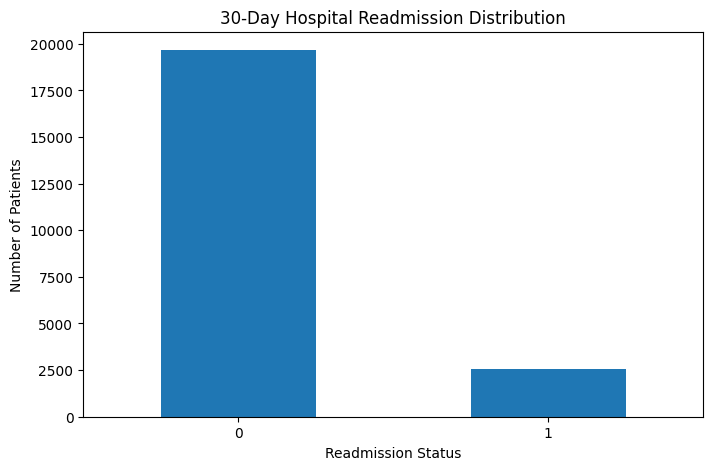

In [11]:
# Step 5.1: Target Distribution

target = "readmission_30_days"

print("Target Column:", target)

print("\nReadmission Counts:")
print(df[target].value_counts())

print("\nReadmission Percentage:")
print(df[target].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(8, 5))

df[target].value_counts().plot(kind="bar")

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

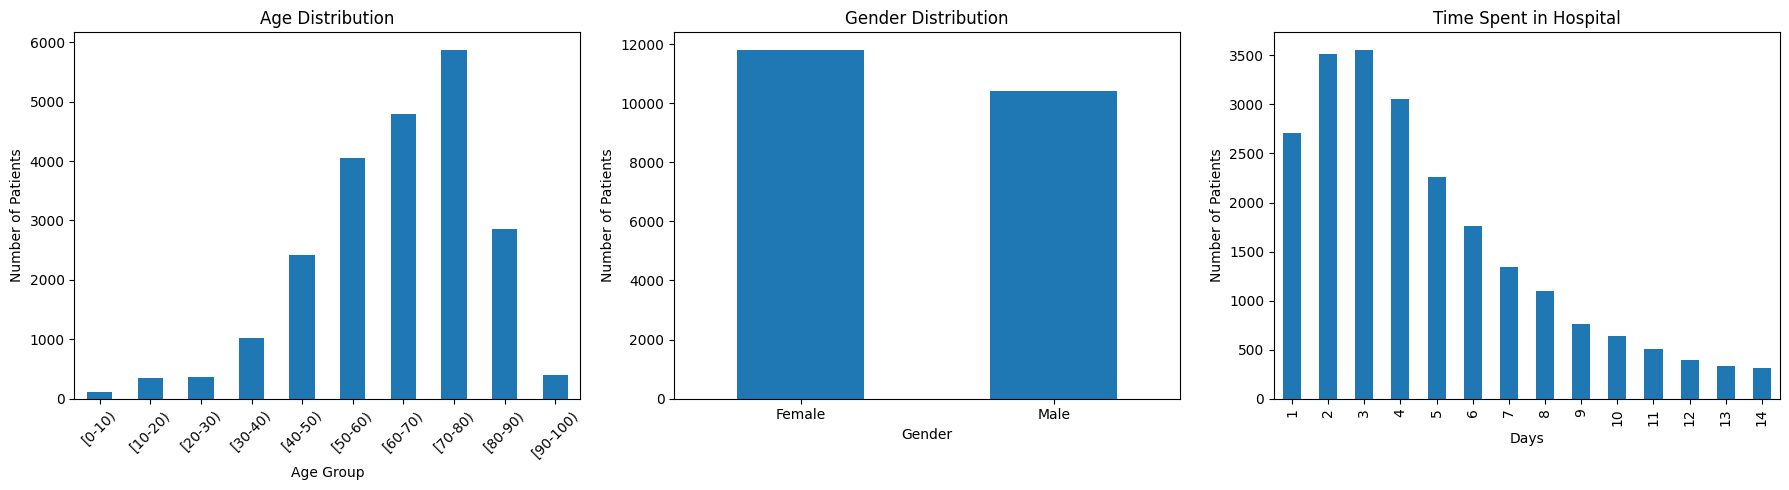

In [12]:
# Step 5.2: Basic EDA Visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
df["age"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis="x", rotation=45)

# Gender distribution
df["gender"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Patients")
axes[1].tick_params(axis="x", rotation=0)

# Time in hospital distribution
df["time_in_hospital"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Time Spent in Hospital")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Readmission Percentage by Age Group:


readmission_30_days,0,1
age,,
[0-10),99.13,0.87
[10-20),94.86,5.14
[20-30),88.77,11.23
[30-40),88.18,11.82
[40-50),88.22,11.78
[50-60),89.95,10.05
[60-70),88.20,11.80
[70-80),87.47,12.53
[80-90),87.08,12.92


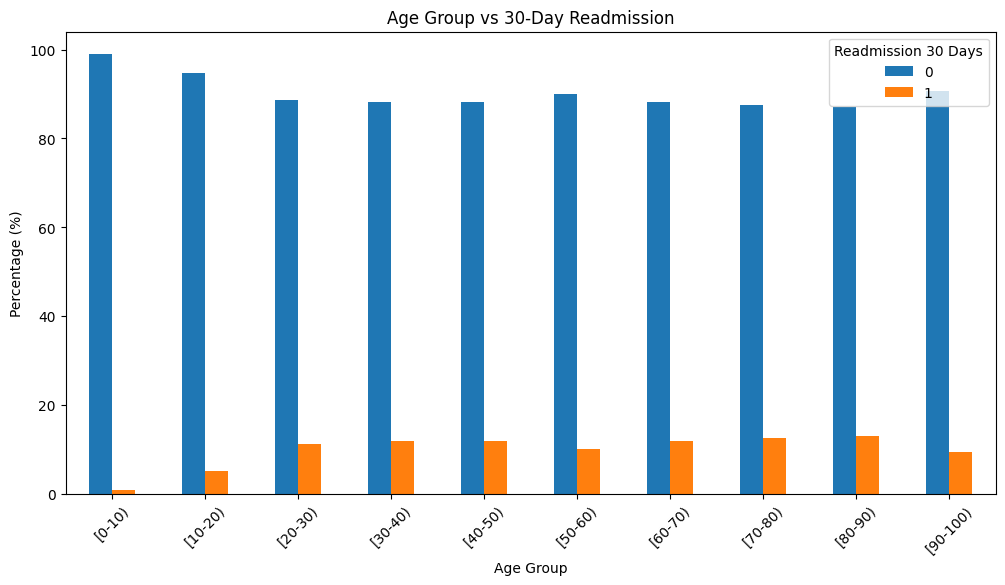

In [13]:
# Step 5.3: Age Group vs 30-Day Readmission

age_readmission = pd.crosstab(
    df["age"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Age Group:")
display(age_readmission.round(2))

# Visualization
age_readmission.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Age Group vs 30-Day Readmission")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Readmission 30 Days")
plt.show()

Readmission Percentage by Gender:


readmission_30_days,0,1
gender,,
Female,88.06,11.94
Male,88.78,11.22


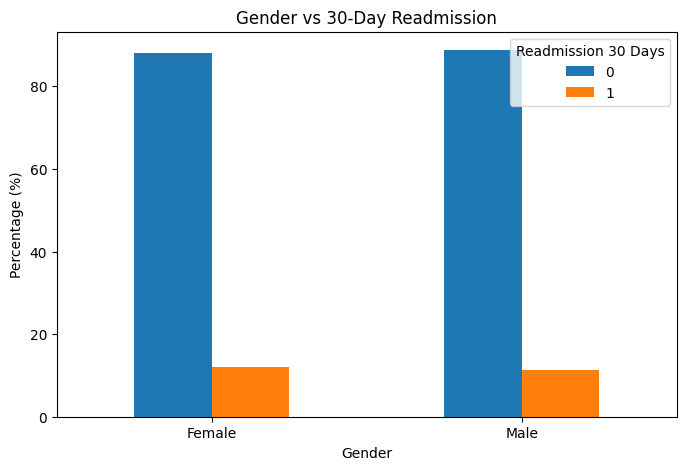

In [14]:
# Step 5.4: Gender vs 30-Day Readmission

gender_readmission = pd.crosstab(
    df["gender"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Gender:")
display(gender_readmission.round(2))

# Visualization
gender_readmission.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Gender vs 30-Day Readmission")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmission 30 Days")
plt.show()

Readmission Percentage by Hospital Stay:


readmission_30_days,0,1
time_in_hospital,,
1,91.70,8.30
2,90.69,9.31
3,89.49,10.51
4,88.79,11.21
5,87.92,12.08
6,85.50,14.50
7,85.58,14.42
8,84.57,15.43
9,85.55,14.45


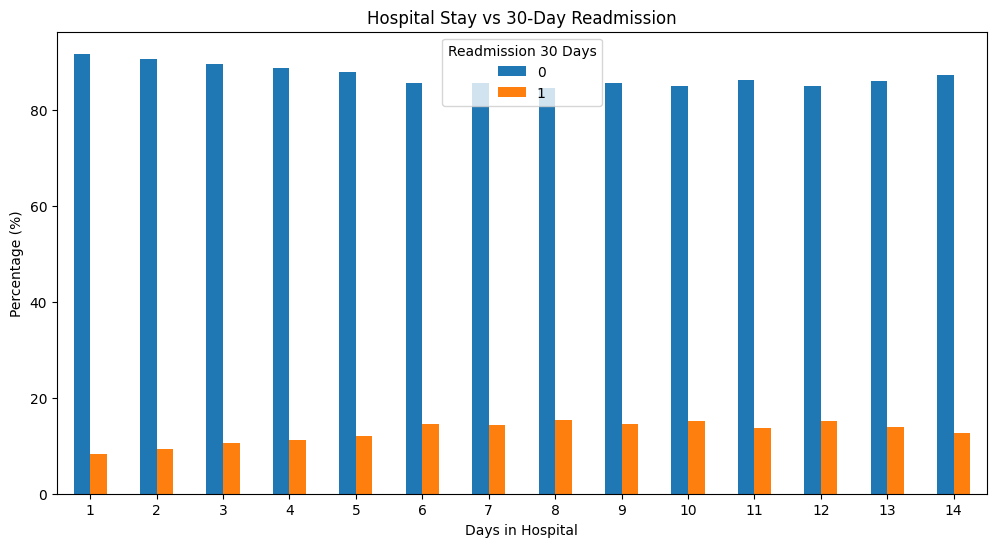

In [15]:
# Step 5.5: Hospital Stay vs 30-Day Readmission

stay_readmission = pd.crosstab(
    df["time_in_hospital"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Hospital Stay:")
display(stay_readmission.round(2))

# Visualization
stay_readmission.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Hospital Stay vs 30-Day Readmission")
plt.xlabel("Days in Hospital")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmission 30 Days")
plt.show()

Readmission Percentage by Previous Inpatient Visits:


readmission_30_days,0,1
number_inpatient,,
0,91.19,8.81
1,85.47,14.53
2,81.05,18.95
3,77.98,22.02
4,78.46,21.54
5,69.43,30.57
6,66.30,33.70
7,54.90,45.10
8,66.67,33.33


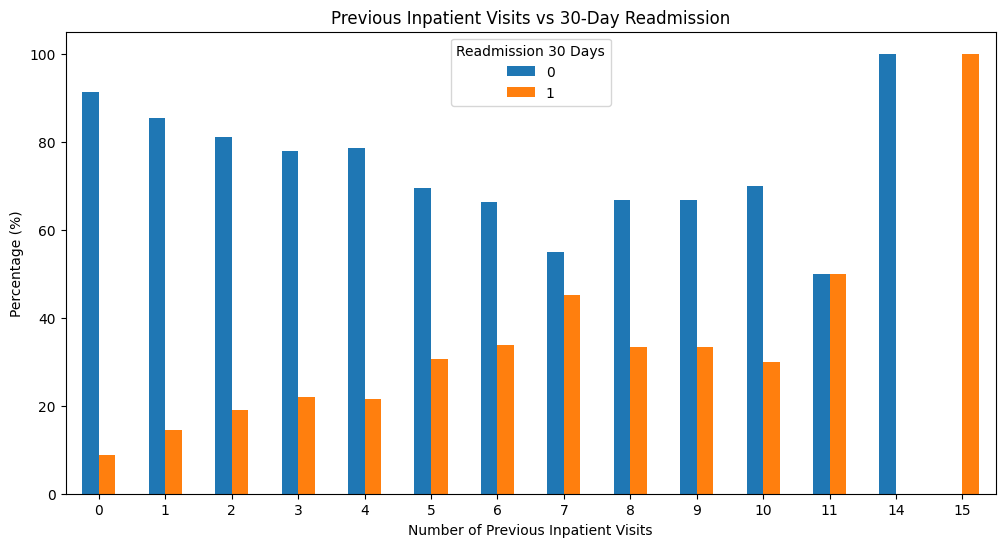

In [16]:
# Step 5.6: Previous Inpatient Visits vs 30-Day Readmission

inpatient_readmission = pd.crosstab(
    df["number_inpatient"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Previous Inpatient Visits:")
display(inpatient_readmission.round(2))

# Visualization
inpatient_readmission.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Previous Inpatient Visits vs 30-Day Readmission")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmission 30 Days")
plt.show()

Readmission Percentage by Number of Medications:


readmission_30_days,0,1
num_medications,,
1,92.59,7.41
2,90.60,9.40
3,93.64,6.36
4,92.56,7.44
5,92.63,7.37
...,...,...
59,100.00,0.00
60,100.00,0.00
61,100.00,0.00


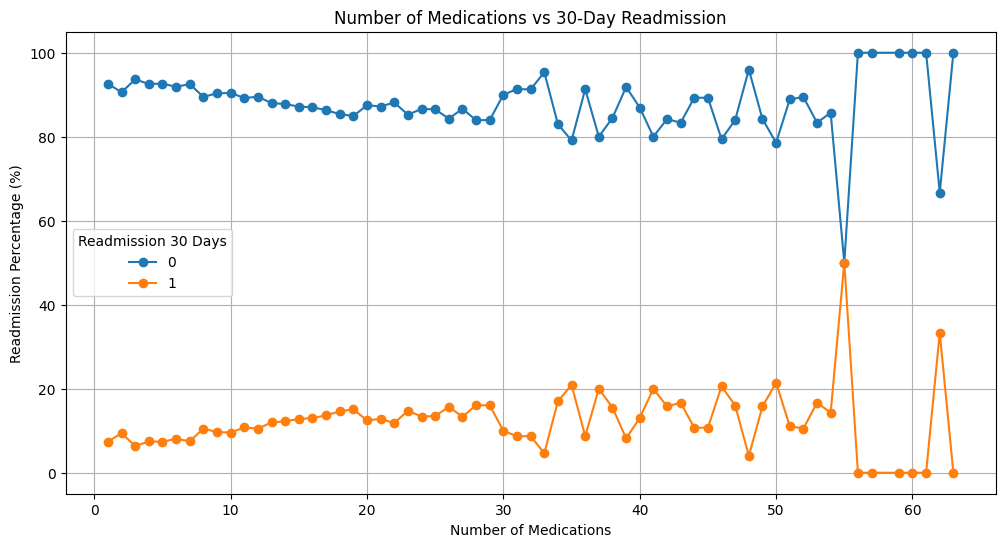

In [17]:
# Step 5.7: Number of Medications vs 30-Day Readmission

medication_readmission = pd.crosstab(
    df["num_medications"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Number of Medications:")
display(medication_readmission.round(2))

# Visualization
medication_readmission.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Number of Medications vs 30-Day Readmission")
plt.xlabel("Number of Medications")
plt.ylabel("Readmission Percentage (%)")
plt.legend(title="Readmission 30 Days")
plt.grid(True)

plt.show()

Readmission Percentage by Number of Lab Procedures:


readmission_30_days,0,1
num_lab_procedures,,
1,91.96,8.04
2,90.41,9.59
3,96.77,3.23
4,93.33,6.67
5,88.37,11.63
...,...,...
107,100.00,0.00
111,100.00,0.00
113,100.00,0.00


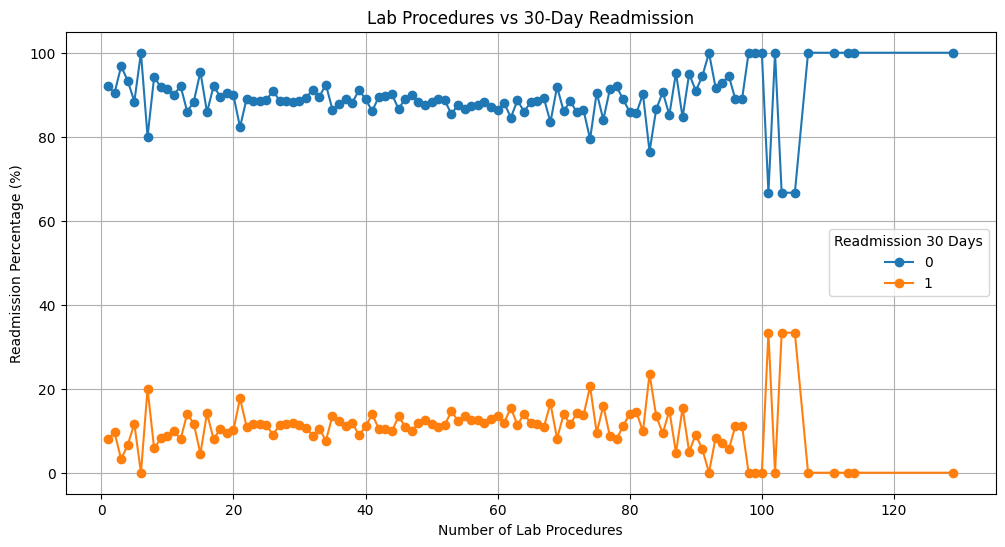

In [18]:
# Step 5.8: Lab Procedures vs 30-Day Readmission

lab_readmission = pd.crosstab(
    df["num_lab_procedures"],
    df["readmission_30_days"],
    normalize="index"
) * 100

print("Readmission Percentage by Number of Lab Procedures:")
display(lab_readmission.round(2))

# Visualization
lab_readmission.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Lab Procedures vs 30-Day Readmission")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Readmission Percentage (%)")
plt.legend(title="Readmission 30 Days")
plt.grid(True)

plt.show()

Correlation with 30-Day Readmission:


,readmission_30_days
readmission_30_days,1.000000
number_inpatient,0.150339
number_diagnoses,0.069020
time_in_hospital,0.062282
num_medications,0.051049
number_emergency,0.047230
num_lab_procedures,0.025155
number_outpatient,0.021930
admission_source_id,0.004848
num_procedures,-0.013032


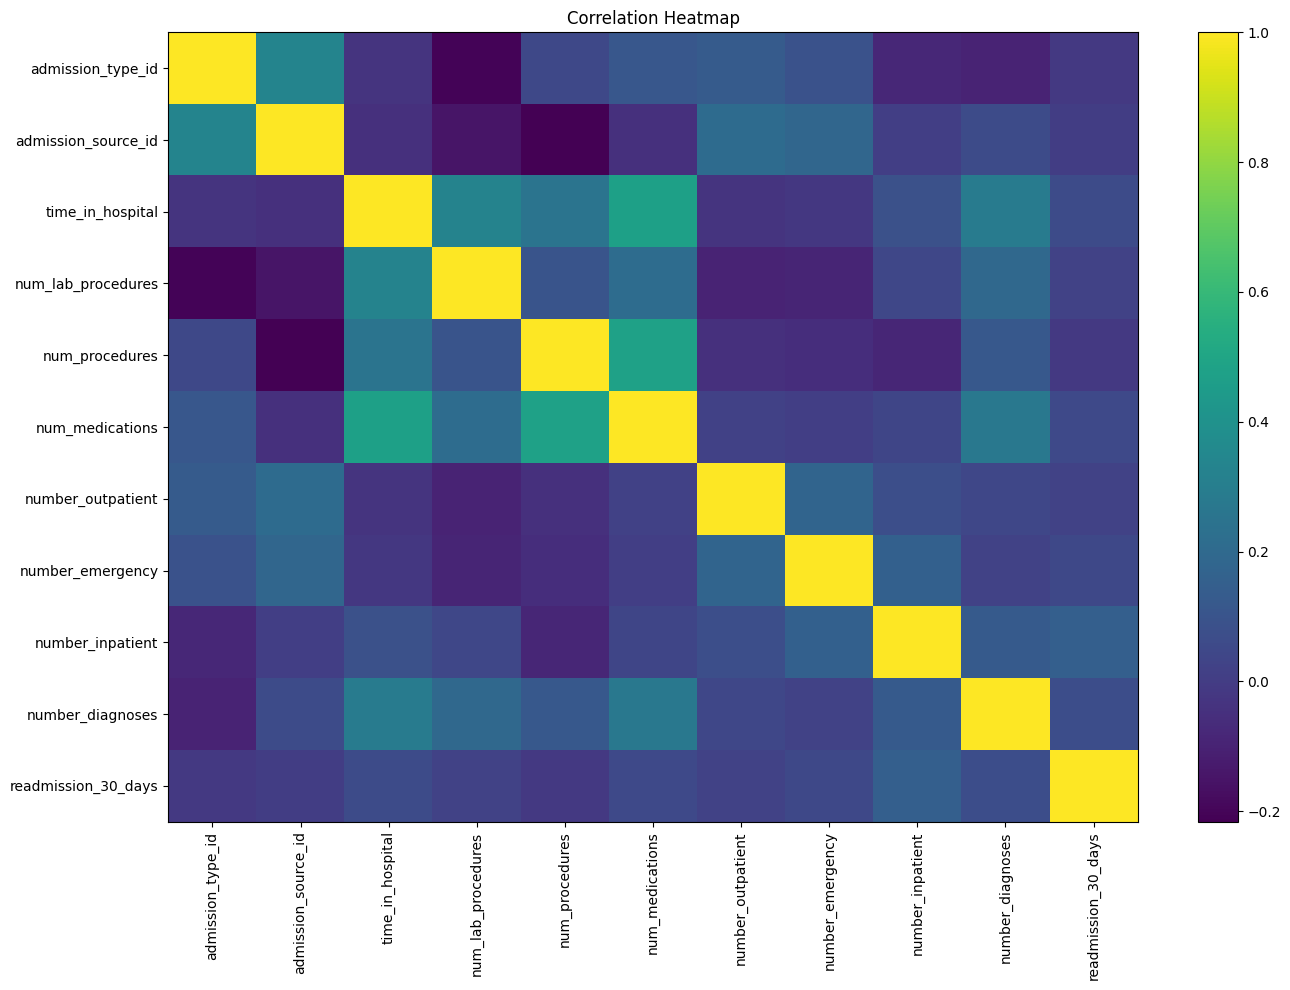

In [19]:
# Step 5.9: Correlation Analysis

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation with target
target_correlation = numeric_df.corr()["readmission_30_days"].sort_values(
    ascending=False
)

print("Correlation with 30-Day Readmission:")
display(target_correlation)

# Heatmap
plt.figure(figsize=(14, 10))

plt.imshow(numeric_df.corr(), aspect="auto")
plt.colorbar()

plt.title("Correlation Heatmap")
plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)
plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.tight_layout()
plt.show()

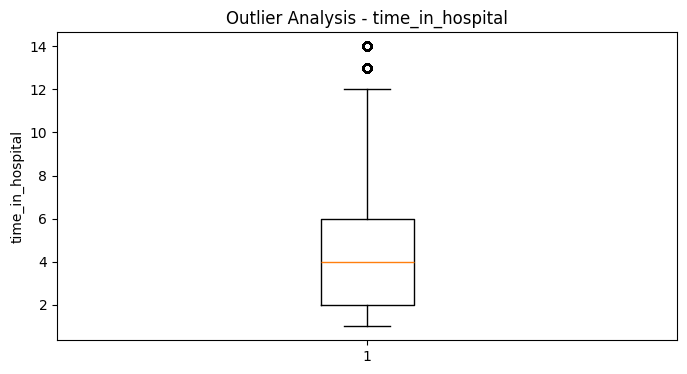

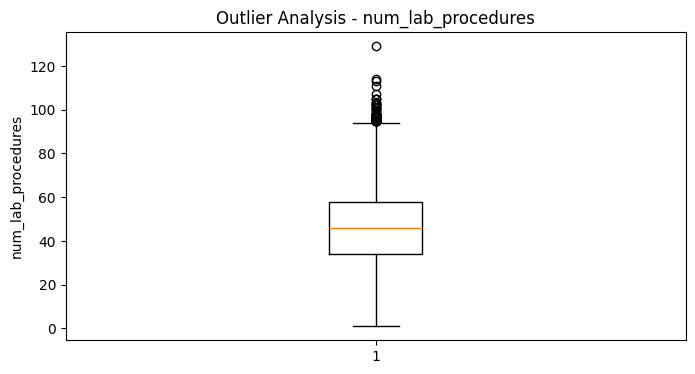

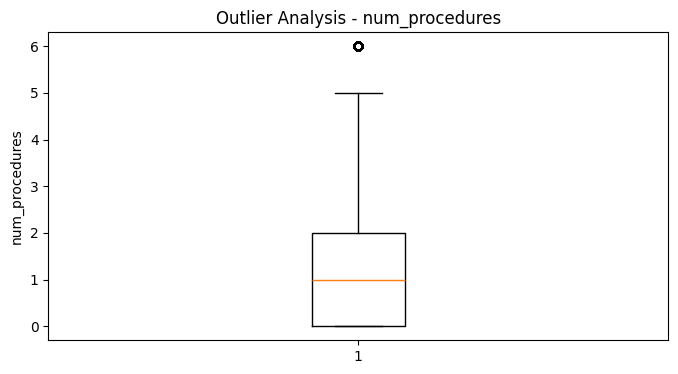

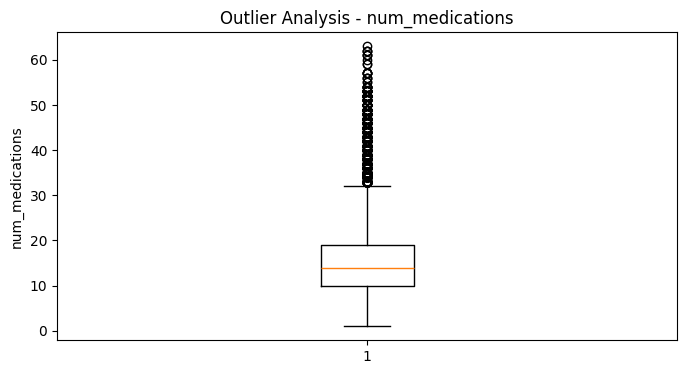

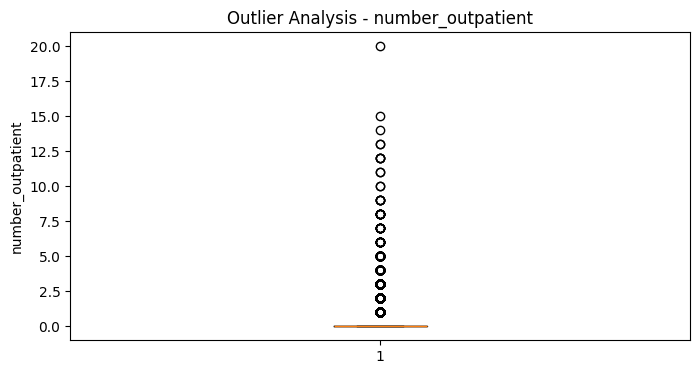

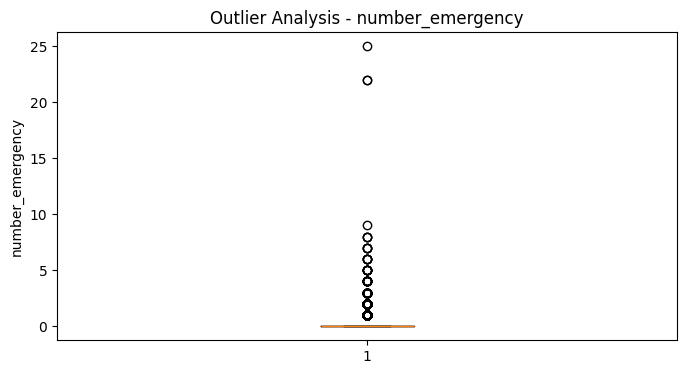

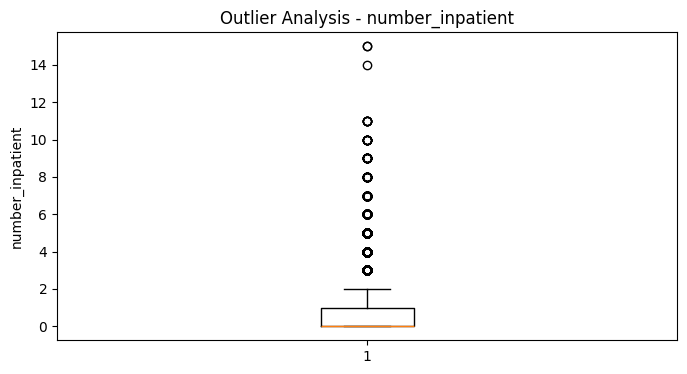

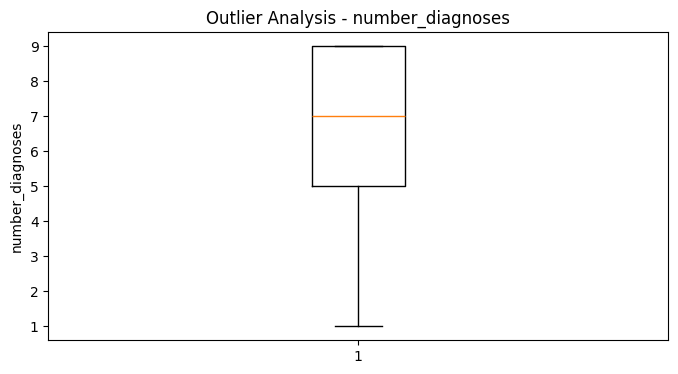

Outlier Counts:
time_in_hospital: 645
num_lab_procedures: 62
num_procedures: 1084
num_medications: 905
number_outpatient: 1571
number_emergency: 928
number_inpatient: 1340
number_diagnoses: 0


In [20]:
# Step 5.10: Outlier Analysis

# Important numerical features
outlier_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Boxplots
for col in outlier_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Outlier Analysis - {col}")
    plt.ylabel(col)
    plt.show()

# IQR-based outlier count
print("Outlier Counts:")
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers}")

In [21]:
# Step 6: Identify categorical and numerical columns

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Numerical Columns:
['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmission_30_days']


In [22]:
# Step 6.1: Check categorical columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(15))


race
race
Caucasian          16233
AfricanAmerican     4765
Hispanic             493
Unknown              352
Other                312
Asian                 91
Name: count, dtype: int64

gender
gender
Female    11816
Male      10430
Name: count, dtype: int64

age
age
[70-80)     5873
[60-70)     4797
[50-60)     4050
[80-90)     2863
[40-50)     2419
[30-40)     1015
[90-100)     399
[20-30)      365
[10-20)      350
[0-10)       115
Name: count, dtype: int64

payer_code
payer_code
Unknown    22242
MC             4
Name: count, dtype: int64

medical_specialty
medical_specialty
Unknown                              8797
InternalMedicine                     4018
Family/GeneralPractice               2674
Cardiology                           1733
Surgery-General                       737
Orthopedics-Reconstructive            431
Orthopedics                           366
Nephrology                            361
Psychiatry                            349
Pulmonology                          

In [23]:
# Step 6.2: Handle Missing Values

# Replace missing values in categorical columns
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Replace missing values in numerical columns
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully!")

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Missing values handled successfully!

Remaining missing values:
0


In [24]:
# Step 6.3: Encode Categorical Variables

target = "readmission_30_days"

# Separate target
X = df.drop(columns=[target])
y = df[target]

# One-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object"]).columns,
    drop_first=True
)

# Convert True/False to 1/0
X_encoded = X_encoded.astype(int)

print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

print("\nEncoded dataset:")
display(X_encoded.head())

Original features: 45
Encoded features: 1786

Encoded dataset:


,admission_type_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,glyburide-metformin_Unknown,glyburide-metformin_Up,glipizide-metformin_Unknown,glimepiride-pioglitazone_Unknown,metformin-rosiglitazone_Unknown,metformin-pioglitazone_Unknown,change_No,change_Unknown,diabetesMed_Unknown,diabetesMed_Yes
0,6,1,1,41,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1,1,7,3,59,0,18,0,0,0,9,...,0,0,0,0,0,0,0,0,0,1
2,1,7,2,11,5,13,2,0,1,6,...,0,0,0,0,0,0,1,0,0,1
3,1,7,2,44,1,16,0,0,0,7,...,0,0,0,0,0,0,0,0,0,1
4,1,7,1,51,0,8,0,0,0,5,...,0,0,0,0,0,0,0,0,0,1


In [25]:
# Step 6.4: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (17796, 1786)
Testing data: (4450, 1786)

Training target distribution:
readmission_30_days
0    0.883963
1    0.116037
Name: proportion, dtype: float64

Testing target distribution:
readmission_30_days
0    0.884045
1    0.115955
Name: proportion, dtype: float64


In [26]:
# Step 6.5: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully!
X_train_scaled shape: (17796, 1786)
X_test_scaled shape: (4450, 1786)


In [27]:
# Step 7: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy_lr, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8737

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3934
           1       0.24      0.04      0.07       516

    accuracy                           0.87      4450
   macro avg       0.56      0.51      0.50      4450
weighted avg       0.81      0.87      0.83      4450


Confusion Matrix:
[[3867   67]
 [ 495   21]]


In [28]:
# Step 7.1: Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.884

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      3934
           1       0.00      0.00      0.00       516

    accuracy                           0.88      4450
   macro avg       0.44      0.50      0.47      4450
weighted avg       0.78      0.88      0.83      4450


Confusion Matrix:
[[3934    0]
 [ 516    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# Step 7.2: Compare Models

from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression metrics
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Random Forest metrics
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Comparison table
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1]
})

display(model_comparison.round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8737,0.2386,0.0407,0.0695
1,Random Forest,0.8840,0.0000,0.0000,0.0000


Top 20 Important Features:


,Feature,Importance
3,num_lab_procedures,0.051512
5,num_medications,0.049436
2,time_in_hospital,0.040629
8,number_inpatient,0.036910
9,number_diagnoses,0.032929
4,num_procedures,0.027128
0,admission_type_id,0.020192
1,admission_source_id,0.020082
15,gender_Male,0.014163
11,race_Caucasian,0.011979


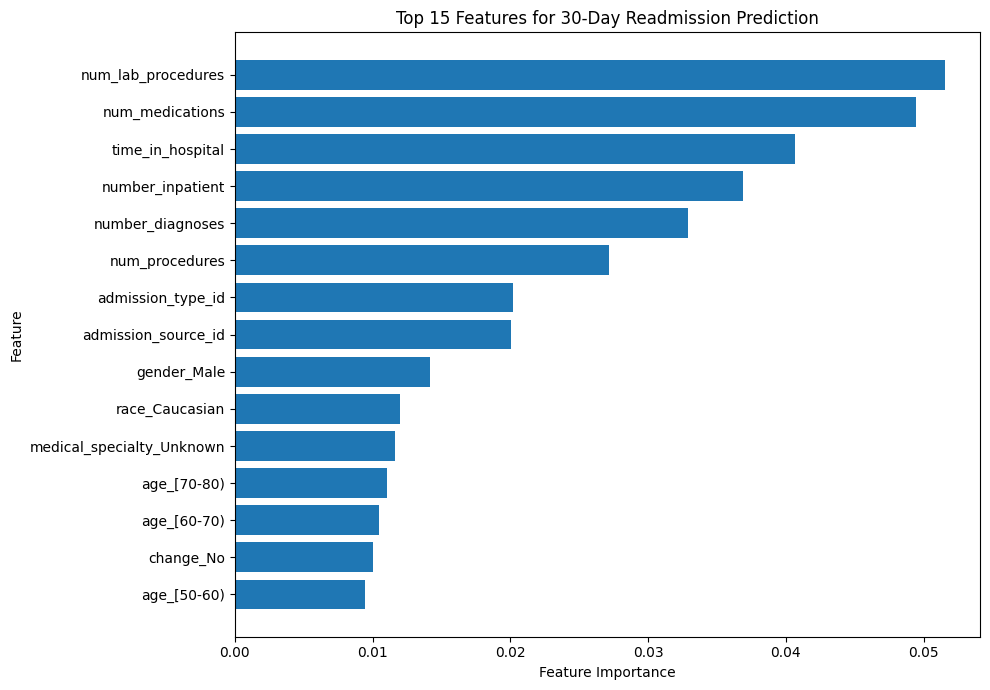

In [30]:
# Step 7.3: Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
display(feature_importance.head(20))

# Visualization
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Features for 30-Day Readmission Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Random Forest ROC-AUC: 0.6514


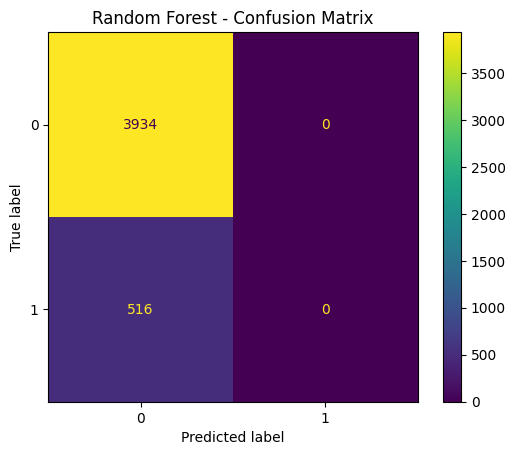

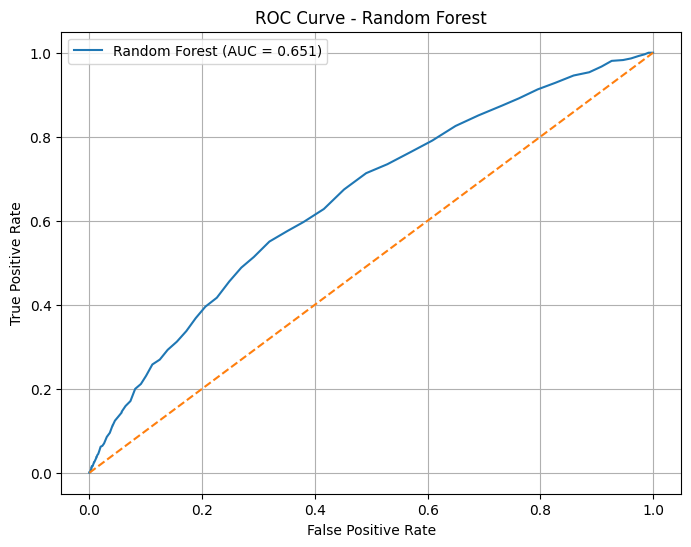

In [31]:
# Step 7.4: Confusion Matrix and ROC-AUC

from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(roc_auc_rf, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Step 8: Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuning.fit(X_train, y_train)

print("Best Parameters:")
print(rf_tuning.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(rf_tuning.best_score_, 4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

Best Cross-Validation F1 Score:
0.2597


In [35]:
# Step 8.1: Evaluate Tuned Random Forest

best_rf = rf_tuning.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(X_test)

# Probabilities
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

# Metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Optimized Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Optimized Random Forest Results
--------------------------------
Accuracy : 0.6434
Precision: 0.1776
Recall   : 0.5717
F1 Score : 0.271
ROC-AUC  : 0.6524

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76      3934
           1       0.18      0.57      0.27       516

    accuracy                           0.64      4450
   macro avg       0.55      0.61      0.52      4450
weighted avg       0.83      0.64      0.71      4450



In [36]:
# Step 8.2: Find a Better Classification Threshold

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score
0,0.20,0.1160,1.0000,0.2078
1,0.25,0.1160,1.0000,0.2078
2,0.30,0.1164,1.0000,0.2085
3,0.35,0.1170,0.9981,0.2095
4,0.40,0.1198,0.9903,0.2138
5,0.45,0.1333,0.9128,0.2326
6,0.50,0.1776,0.5717,0.2710
7,0.55,0.3114,0.1008,0.1523
8,0.60,0.0000,0.0000,0.0000
9,0.65,0.0000,0.0000,0.0000


In [37]:
# Step 8.3: Select Best Threshold

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1 Score:", round(best_threshold_row["F1 Score"], 4))

Best Threshold: 0.5
Precision: 0.1776
Recall: 0.5717
F1 Score: 0.271


In [38]:
# Step 9: Save Final Model and Preprocessing Objects

import joblib

# Final predictions using selected threshold
final_predictions = (
    y_prob_tuned >= best_threshold
).astype(int)

# Final model performance
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(
    y_test, final_predictions, zero_division=0
)
final_recall = recall_score(
    y_test, final_predictions, zero_division=0
)
final_f1 = f1_score(
    y_test, final_predictions, zero_division=0
)

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("Threshold:", best_threshold)

# Save trained model
joblib.dump(best_rf, "/content/healthcare_readmission_model.pkl")

# Save scaler
joblib.dump(scaler, "/content/healthcare_scaler.pkl")

# Save feature columns
joblib.dump(
    X_encoded.columns.tolist(),
    "/content/healthcare_feature_columns.pkl"
)

# Save threshold
joblib.dump(
    best_threshold,
    "/content/healthcare_threshold.pkl"
)

print("\nAll model files saved successfully!")

FINAL MODEL PERFORMANCE
-----------------------
Accuracy : 0.6434
Precision: 0.1776
Recall   : 0.5717
F1 Score : 0.271
Threshold: 0.5

All model files saved successfully!


In [39]:
# Step 10: Patient Readmission Prediction System

import joblib
import pandas as pd

# Load saved model
model = joblib.load("/content/healthcare_readmission_model.pkl")
feature_columns = joblib.load("/content/healthcare_feature_columns.pkl")
threshold = joblib.load("/content/healthcare_threshold.pkl")

def predict_readmission(patient_data):

    # Convert patient data into DataFrame
    patient_df = pd.DataFrame([patient_data])

    # One-hot encode categorical variables
    patient_encoded = pd.get_dummies(patient_df)

    # Make sure columns match training data
    patient_encoded = patient_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Prediction probability
    probability = model.predict_proba(patient_encoded)[:, 1][0]

    # Apply selected threshold
    prediction = int(probability >= threshold)

    if prediction == 1:
        result = "High Risk: 30-day readmission predicted"
    else:
        result = "Low Risk: 30-day readmission not predicted"

    return {
        "Readmission Probability": round(probability, 4),
        "Prediction": prediction,
        "Result": result
    }

print("Prediction system created successfully!")

Prediction system created successfully!


In [40]:
# Step 10.1: Test Prediction on a Sample Patient

sample_patient = df.drop(columns=["readmission_30_days"]).iloc[0].to_dict()

result = predict_readmission(sample_patient)

print("PATIENT READMISSION PREDICTION")
print("--------------------------------")
print("Readmission Probability:",
      result["Readmission Probability"])
print("Prediction:",
      result["Prediction"])
print("Result:",
      result["Result"])

PATIENT READMISSION PREDICTION
--------------------------------
Readmission Probability: 0.2921
Prediction: 0
Result: Low Risk: 30-day readmission not predicted
